In [1]:
# %pip install xarray pandas 
# %pip install --user cftime, scipy, netCDF4, h5netcdf

import xarray as xr
import glob
import pandas as pd
import sys
import os
notebook_dir = os.path.dirname(os.path.abspath('SSA_MEC_scatter_plot.ipynb'))
project_root = os.path.dirname(notebook_dir)
py_dir = os.path.join(project_root, 'py')

# Add paths to sys.path if not already present
if project_root not in sys.path:
    sys.path.insert(0, project_root)
if py_dir not in sys.path:
    sys.path.insert(0, py_dir)

print(f"Project root: {project_root}")
print(f"Python directory: {py_dir}")
print(f"System path updated: {sys.path[:3]}")


Project root: /net/sys/pscst201/IT-ITVO-HPC@ada-nodes/guest/gbb083/AeroCom
Python directory: /net/sys/pscst201/IT-ITVO-HPC@ada-nodes/guest/gbb083/AeroCom/py
System path updated: ['/net/sys/pscst201/IT-ITVO-HPC@ada-nodes/guest/gbb083/AeroCom/py', '/net/sys/pscst201/IT-ITVO-HPC@ada-nodes/guest/gbb083/AeroCom', '']


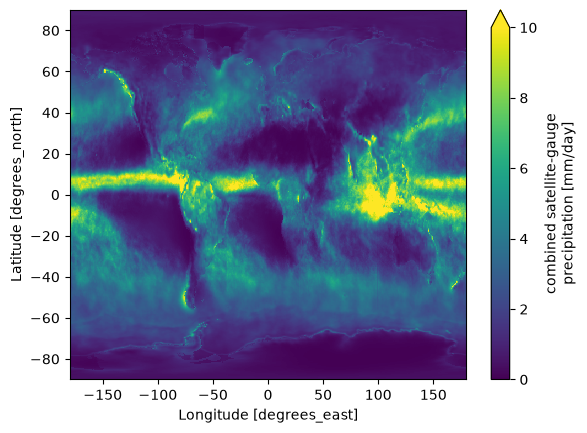

In [ ]:
Prec_files = glob.glob(f'{project_root}/Data/Prec/*')
Prec_files 
Prec = xr.open_mfdataset(Prec_files)
Prec
# sat_gauge_precip
# sat_gauge_absolute_bias_error
# sat_gauge_absolute_random_error
Prec ['sat_gauge_precip'].mean(dim='time').plot(cmap='viridis', vmin=0, vmax=10) 

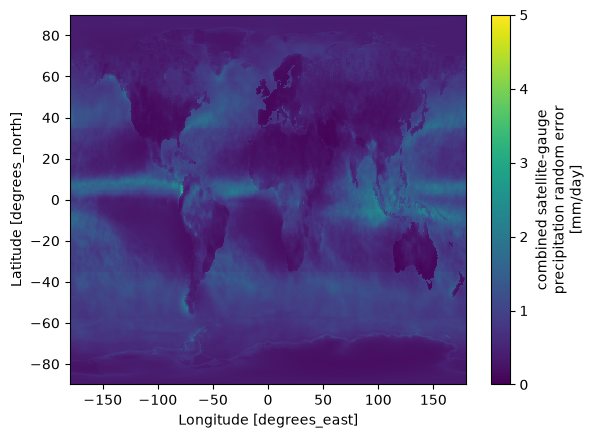

In [24]:
Prec ['sat_gauge_random_error'].mean(dim='time').plot(cmap='viridis', vmin=0, vmax=5) 

In [14]:

POLDER_files = glob.glob(f'{project_root}/Data/POLDER_GRASP/*2010*')
# POLDER_files 
POLDER = xr.open_dataset(POLDER_files[0])
POLDER['time'].values



array(['2010-01-01T16:57:35.999989824', '2010-01-01T16:57:35.999989824',
       '2010-01-01T23:32:16.000013376', ...,
       '2010-01-31T22:43:12.000009088', '2010-01-31T22:43:12.000009088',
       '2010-01-31T22:43:12.000009088'],
      shape=(191607,), dtype='datetime64[ns]')

# Polder dataframe <-> add all model data behind in a dataframe 
XARRAY polder data monthly file consists of following var 
Data variables:
    longitude  (data_length) float32 766kB ...
    latitude   (data_length) float32 766kB ...
    time       (data_length) datetime64[ns] 2MB 2010-01-01T16:57:35.999989824...
    od440aer   (data_length) float32 766kB ...
    abs440aer  (data_length) float32 766kB ... 
    od550aer   (data_length) float32 766kB ...
    abs550aer  (data_length) float32 766kB ...
    od870aer   (data_length) float32 766kB ...
    abs870aer  (data_length) float32 766kB ...
RENAME abs AAOD  
df_aod_polder <-> alpache parquet 
time longitude latitude AOD_440 AAOD_440 

In [28]:
POLDER


<xarray.Dataset> Size: 8MB
Dimensions:    (data_length: 191607)
Dimensions without coordinates: data_length
Data variables:
    longitude  (data_length) float32 766kB ...
    latitude   (data_length) float32 766kB ...
    time       (data_length) datetime64[ns] 2MB 2010-01-01T16:57:35.999989824...
    od440aer   (data_length) float32 766kB ...
    abs440aer  (data_length) float32 766kB ...
    od550aer   (data_length) float32 766kB ...
    abs550aer  (data_length) float32 766kB ...
    od870aer   (data_length) float32 766kB ...
    abs870aer  (data_length) float32 766kB ...
Attributes:
    Platform:       PARASOL
    Sensor:         POLDER
    Author:         O. Dubovik
    Institute:      U. Lille
    Product:        GRASP models L3 v2.1, corrected AAOD=(1.-SSA)*AOD, mild r...
    Method:         Linear interpolation in wavelength
    Creation_Date:  20200930
    Comment:        Reformatting of original data

In [ ]:
POLDER['od550aer'].mean(dim='time').plot(cmap='viridis', vmin=0)  
